# Final Assignment Tutorial — Telecom

This notebook is a reference walkthrough for the GCI World 2026 Spring final assignment.
The dataset comes from **Company A**, an anonymous telecommunications service provider, and contains historical customer information across two linked tables (`Client.csv`, `Record.csv`).

Your task is to analyze this data, build a machine learning model whose output supports a concrete business proposal — not to build the best possible model.

**What this notebook walks through:**
1. Market context.
2. Loading and merging the two source tables.
3. EDA: shape, missingness, target distribution, and a worked feature example.
4. Problem Definition — choosing the target and the ML task.
5. Preprocessing — what EDA told us we have to do.
6. A baseline churn classifier.
7. Model evaluation and feature importance.
8. From model to business proposal.

> **Treat this as a reference, not a template.** The strongest submissions diverge from it: a different target, a different segment, a different lever. Originality is rewarded.


---

## 1.Introduction & Market Analysis


### 1.1 Company context
*Company A* is a wireless telecommunications operator. They have years of usage and billing data on roughly 100,000 customers but no in-house machine learning capability.

When a company commissions a business proposal, they usually arrive with a vague sense that *something* needs to improve — margins, retention, growth, customer satisfaction — but no clear view of which lever to pull, which segment to focus on, or even which question to start with. **Choosing the question is the analyst's first job, and the rest of the proposal stands or falls on it.** The dataset rarely points to a single obvious answer; it admits several, and which one you pursue determines the kind of recommendation you can make.

This dataset includes a binary `churn` flag — whether a customer left within 31–60 days after the observation date — and we use churn as the worked example throughout this notebook. But churn is one of many viable targets the data supports. **You may and should explore other targets** — revenue, usage, equipment lifecycle, segment-level behaviour. Pick the question whose answer best supports the proposal you want to make.

### 1.2 Why this market matters
- Acquiring a new subscriber costs several times more than keeping one — retention, usage, and ARPU all translate directly into margin.
- Mature, saturated markets grow by taking customers from competitors or lifting revenue per existing customer.
- Behaviour signals (usage decline, complaints, equipment ageing) precede both churn and revenue compression by months.

**Questions to think about:**
- What does the telecom market look like in your country or region — who are the major players, what local dynamics (regulation, technology shifts, new entrants) are reshaping churn, and what story can you tell about a specific market you know? A proposal grounded in a local market you can describe concretely is more compelling than one assembled from generic global figures.
- What recent, citable sources can you find that quantify these claims for your target market? Uncited industry numbers will not strengthen your case.
- What share of churn in this market is voluntary (customer-initiated) versus involuntary (non-payment, address change)? Which one can a model meaningfully address?

---

## 2.Setup and Data Loading


### 2.1 Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from xgboost import XGBClassifier, plot_importance

pd.set_option("display.max_columns", 120)


### 2.2 Connect to Google Drive

If you are running this notebook on Google Colab, mount your Drive and `cd` into the folder that contains the dataset.


In [3]:
# Run this cell only on Google Colab.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**IMPORTANT**:<br>
Change the path in the `%cd` command below to match the folder where this notebook is saved on Google Drive by **replacing "WhereThisNotebookIsLocated" with your actual folder path**.

Example:
- You uploaded `Final Assignment` folder directly under MyDrive (the default folder when you open Google Drive)
    - Change to "/<wbr>content/drive/MyDrive/Final Assignment"

You can easily locate your notebook's directory by:
1. Open the Files panel on the left side of Colab
2. Navigate through the "drive" and "MyDrive" folders until you find your notebook's folders
3. Click the more actions icon (three vertical dots, $\vdots$) next to the folder name
4. Select the option "Copy path"

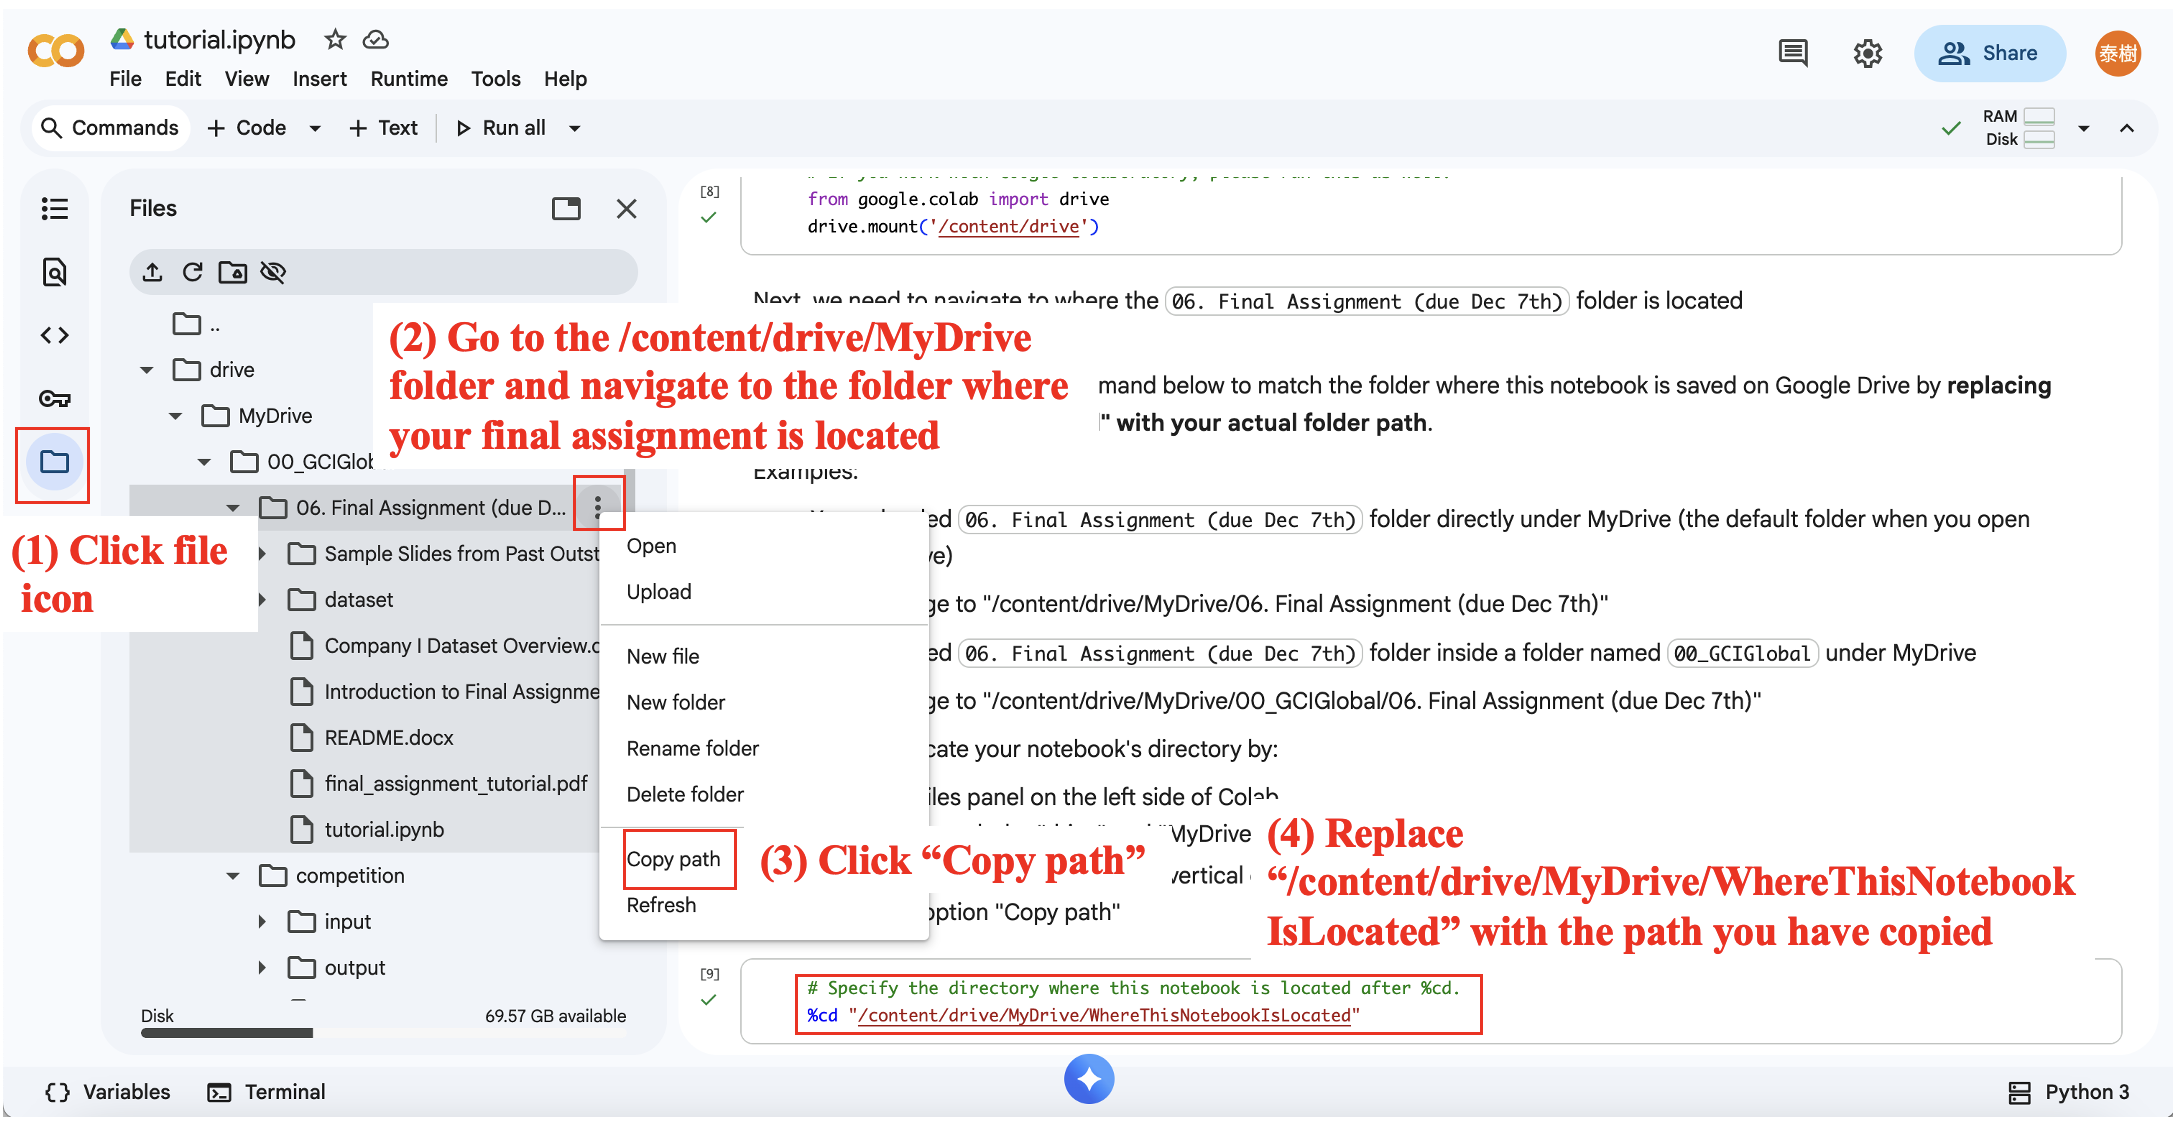

In [4]:
#%cd "/content/drive/MyDrive/WhereThisNotebookIsLocated"
%cd "/content/drive/MyDrive/Final Assignment"

/content/drive/MyDrive/Final Assignment


### 2.3 Load the two source tables

The dataset is split across two files:

| File | Granularity | Contents |
|---|---|---|
| `Client.csv` | one row per customer | account-level info: tenure, plan, demographics, equipment |
| `Record.csv` | one row per customer | mean monthly usage, billing, and call-quality metrics, plus the `churn` target |

Both tables share a `Customer_ID` column, which we use to join them into a single analysis table.


In [5]:
import os
from pathlib import Path

current_dir = Path(os.getcwd())
client_path = current_dir / "telecom" / "Client.csv"
record_path = current_dir / "telecom" / "Record.csv"

for p in (client_path, record_path):
    print(f"{'OK ' if p.exists() else 'MISSING '} {p}")

OK  /content/drive/MyDrive/Final Assignment/telecom/Client.csv
OK  /content/drive/MyDrive/Final Assignment/telecom/Record.csv


In [6]:
client = pd.read_csv(client_path)
record = pd.read_csv(record_path)

print(f"Client: {client.shape}")
print(f"Record: {record.shape}")

Client: (100000, 50)
Record: (100000, 51)


In [7]:
# Merge on Customer_ID. Both tables have one row per customer, so this is a 1:1 join.
df = record.merge(client, on='Customer_ID', how='inner')
print(f"Merged: {df.shape}")
df.head()

Merged: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0


---

## 3.Exploratory Data Analysis

Before modeling, three questions need answers:

1. **How big and structured is the data?** Rows, columns, dtypes.
2. **Where is the data incomplete or unreliable?**
3. **What does the target variable look like?**

Each answer constrains the next step. The shape and types tell us what preprocessing is required. The missingness tells us which columns may need to be dropped, imputed, or treated specially. The target distribution tells us which metrics will be meaningful.

EDA is also where the proposal starts to take shape — the patterns you see now become candidate signals for the model and anchors for the story your proposal will tell. The visualizations in this tutorial are intentionally minimal — just enough to make a point; for your proposal slides, you will want to polish them.

### 3.1 Shape and types

`df.info(verbose=False)` reports total rows, total columns, the count of columns of each dtype, and memory use. Two things to read from the output:

- **Dataset size.** Small enough to keep in pandas — no chunking needed.
- **Dtype mix.** Some columns may be stored as `object` (text). Most machine learning models can only learn from numbers, so any text columns will need to be converted to numeric form before modeling.

In [8]:
df.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 100 entries, rev_Mean to eqpdays
dtypes: float64(69), int64(10), object(21)
memory usage: 76.3+ MB


### 3.2 Missing values

A column that is mostly missing carries little signal — dropping it is often cleaner than trying to impute. We count the missing values in each column, take the 20 worst, and plot them.

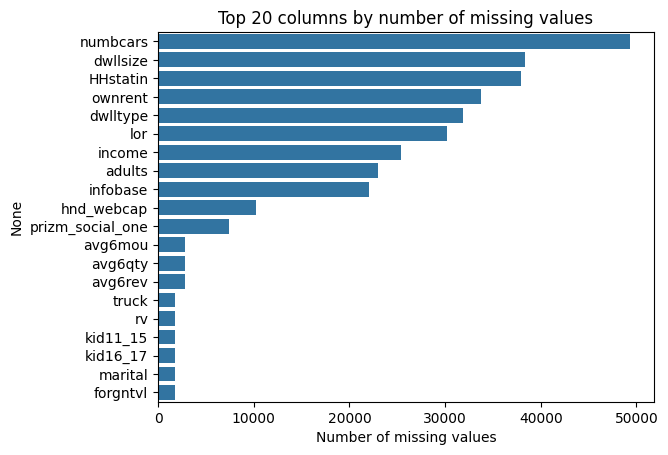

In [9]:
# Count of missing values per column
missing_counts = df.isna().sum()

# Take the 20 columns with the most missing values
top_missing = missing_counts.sort_values(ascending=False).head(20)

# Plot
sns.barplot(x=top_missing.values, y=top_missing.index)
plt.xlabel('Number of missing values')
plt.title('Top 20 columns by number of missing values')
plt.show()

### 3.3 Target variable: churn

We'll use `churn` as the worked example. Before modeling we need its class balance — whether stayers and churners appear in roughly equal numbers, or whether one class dominates. The balance directly affects which evaluation metric will be meaningful: accuracy is informative only when classes are balanced; with 5% churn it would be misleading.

churn
0    50438
1    49562
Name: count, dtype: int64

churn
0    0.50438
1    0.49562
Name: proportion, dtype: float64


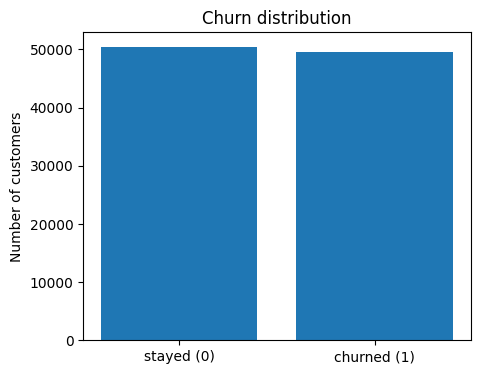

In [10]:
# Counts and proportions
print(df['churn'].value_counts())
print()
print(df['churn'].value_counts(normalize=True))

# Bar chart
counts = df['churn'].value_counts().sort_index()
labels = ['stayed (0)', 'churned (1)']

plt.figure(figsize=(5, 4))
plt.bar(labels, counts.values)
plt.title('Churn distribution')
plt.ylabel('Number of customers')
plt.show()

Churn is near 50% — unusually balanced for telecom (real-world datasets are typically 5–10% churn). For this dataset, accuracy will be a meaningful metric, and a model that always predicts one class will score around 0.5. If you choose a different target, redo this balance check before picking your evaluation metric.

### 3.4 A closer look: equipment age vs churn

The three checks above are dataset-wide. The real EDA work is digging into individual features — how each one relates to the target, where the differences are, and which patterns are worth following up on.

As one example: `eqpdays` records the age (in days) of each customer's current handset. Old equipment plausibly drives churn — a frustrating or outdated device makes the next contract renewal less attractive. We can check this by comparing the equipment-age distribution for churners against stayers.

Mean equipment age (stayed):  363.3 days
Mean equipment age (churned): 421.1 days


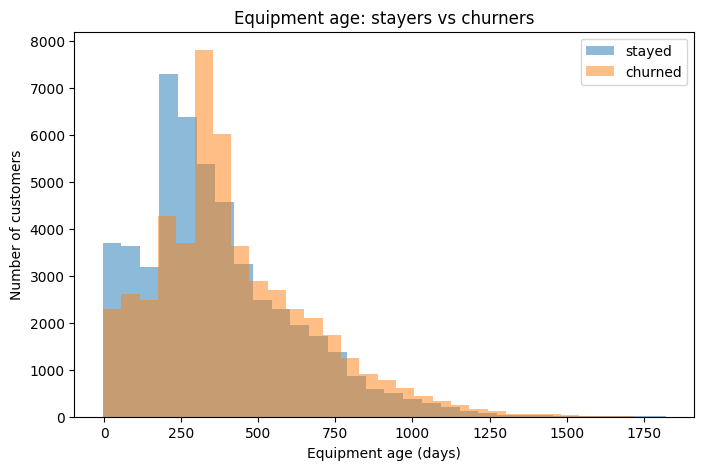

In [11]:
# Split eqpdays into two groups based on churn
stayed = df[df['churn'] == 0]['eqpdays']
churned = df[df['churn'] == 1]['eqpdays']

# Compare the averages
print(f'Mean equipment age (stayed):  {stayed.mean():.1f} days')
print(f'Mean equipment age (churned): {churned.mean():.1f} days')

# Overlay the two distributions
plt.figure(figsize=(8, 5))
plt.hist(stayed, bins=30, alpha=0.5, label='stayed')
plt.hist(churned, bins=30, alpha=0.5, label='churned')
plt.xlabel('Equipment age (days)')
plt.ylabel('Number of customers')
plt.title('Equipment age: stayers vs churners')
plt.legend()
plt.show()

Churners skew toward older equipment — the mean and the right tail of the distribution are both higher than for stayers. That makes `eqpdays` a candidate feature for both the model and the narrative your proposal will tell ("customers with ageing handsets are at higher risk; replacing or upgrading equipment is a lever").

The point is the **exercise**: pick a candidate feature, compare it across churn classes, and decide whether it is worth following up on. Repeat this on a handful of features that look promising from the dataset overview or your domain knowledge.

**Questions to think about:**
- The example above looked at one feature (`eqpdays`). Pick three or four other candidates — from the dataset overview, from Section 1.2, or from your own intuition — and run the same comparison.
- ~100 columns is a lot. Which look like near-duplicates of each other (e.g., several variations on revenue or minutes)?
- Are any columns *too good to be true* — could they leak the target?
- How does the target distribute across segments (geographic, plan, demographic, credit class)? Which segments behave differently and might deserve separate analysis?
- Are there outliers or implausible values you should clean before modeling?

### 3.5 Pairwise view: revenue, usage, equipment age, and churn

The previous plot looked at one feature at a time.  
Here we compare several business-relevant numeric features together:

- `rev_Mean`: average monthly revenue
- `mou_Mean`: average monthly minutes of use
- `totmrc_Mean`: average monthly recurring charge
- `eqpdays`: equipment age in days
- `months`: customer tenure

A pairplot helps us see whether churned customers occupy different regions in the joint feature space.

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


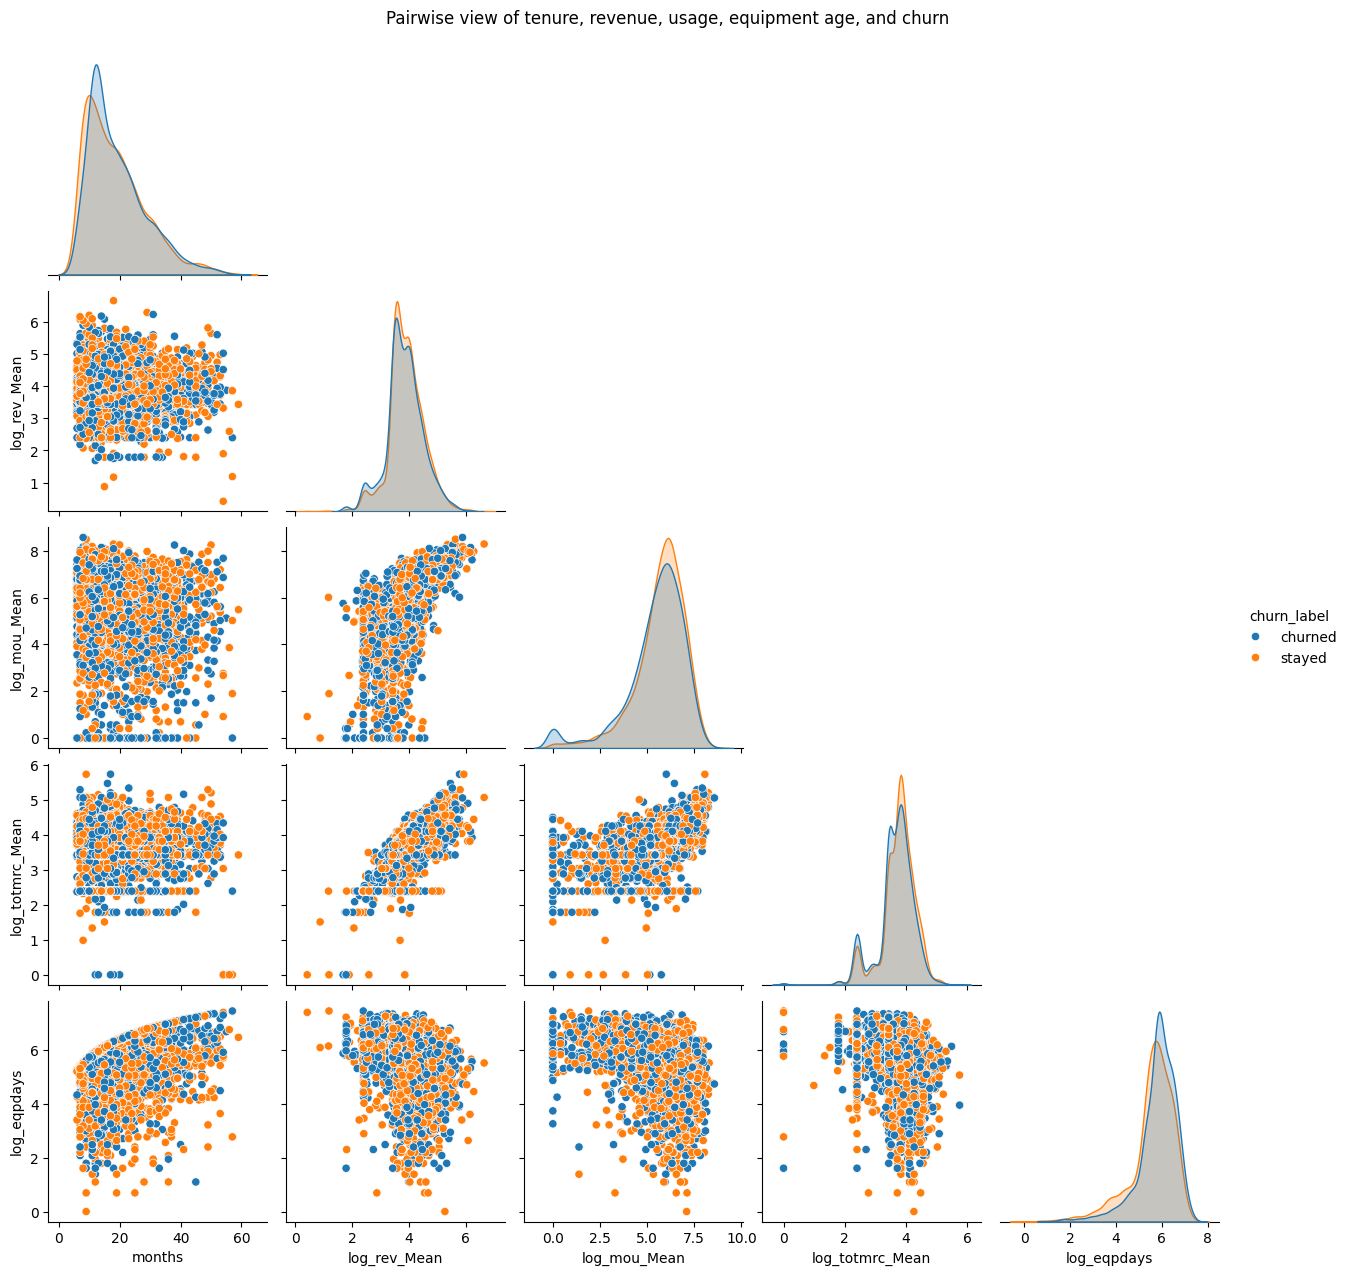

In [12]:
# Pairplot with log-transformed skewed variables
plot_df = df[[
    'months',
    'rev_Mean',
    'mou_Mean',
    'totmrc_Mean',
    'eqpdays',
    'churn'
]].dropna().copy()

# Log-transform highly skewed positive variables
plot_df['log_rev_Mean'] = np.log1p(plot_df['rev_Mean'])
plot_df['log_mou_Mean'] = np.log1p(plot_df['mou_Mean'])
plot_df['log_totmrc_Mean'] = np.log1p(plot_df['totmrc_Mean'])
plot_df['log_eqpdays'] = np.log1p(plot_df['eqpdays'])

plot_df['churn_label'] = plot_df['churn'].map({
    0: 'stayed',
    1: 'churned'
})

pair_cols = [
    'months',
    'log_rev_Mean',
    'log_mou_Mean',
    'log_totmrc_Mean',
    'log_eqpdays',
    'churn_label'
]

pair_sample = plot_df[pair_cols].sample(n=5000, random_state=42)

sns.pairplot(
    pair_sample,
    hue='churn_label',
    corner=True,
    diag_kind='kde',
)

plt.suptitle('Pairwise view of tenure, revenue, usage, equipment age, and churn', y=1.02)
plt.show()

The pairplot does not show a clean geometric separation between churners and non-churners.
This suggests that churn is not explained by a single simple numeric variable such as revenue or usage alone.
However, the diagonal distributions indicate that equipment age (`eqpdays`) is somewhat shifted for churned customers, making it a more interpretable candidate for business intervention.
Revenue- and usage-related variables appear correlated with each other, so they may act as overlapping proxies rather than independent explanations.

---

## 4.Problem Definition

The grading rubric scores your **business proposal**, not your model. The model is one input to the proposal — evidence that supports a specific recommendation. Before any preprocessing or modeling, write down — in a few sentences — what you are actually trying to solve, and what your proposal will ultimately recommend.

**Questions to think about:**
- Is `churn` really the right outcome for *your* proposal? Could revenue, usage, equipment turnover, or something segment-specific be a better fit? Justify your choice from what you saw in EDA.
- What ML task does your target imply — classification, regression, clustering, anomaly detection? Each implies different metrics and a different kind of recommendation.
- How would you state your business question in one sentence a non-technical executive would understand?
- Who acts on the model's output, and what action do they take? A model whose output cannot be acted on is not a proposal.
- What concrete recommendation do you expect your proposal to make? The modeling work in the rest of the notebook should serve that recommendation.

The rest of this notebook proceeds with `churn` as a worked example — but every section is replaceable.

---

## 5.Preprocessing

EDA showed two things that need handling before we can train a model:

- Section 3.1 showed there are `object`-dtype columns. Most ML models can only learn from numbers, so these must be encoded.
- The data also includes `Customer_ID`, a unique identifier with no predictive value. Leaving it in lets the model "memorise" individuals and can destabilise feature importance.

The minimum we have to do is therefore: drop the ID, and convert each `object` column to integers. `LabelEncoder` maps each unique string to a distinct integer. It is the simplest possible encoder, and it makes two compromises worth knowing about:

- It imposes an arbitrary order on categories that have no natural one (e.g. `A=0, B=1, C=2` — the model sees `C` as "larger" than `A`).
- Casting to string first turns `NaN` into the literal string `"nan"`, so missing categorical values become just another category.

In [13]:
# Drop the ID column
df_clean = df.drop(columns=['Customer_ID'])

# Find all columns that are stored as text (object dtype)
object_cols = df_clean.select_dtypes(include='object').columns.tolist()
print('Columns to encode:', object_cols)

# Encode each text column as integers
for col in object_cols:
    encoder = LabelEncoder()
    df_clean[col] = encoder.fit_transform(df_clean[col].astype(str))

print()
print('Shape after preprocessing:', df_clean.shape)
df_clean.head()

Columns to encode: ['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype', 'marital', 'infobase', 'HHstatin', 'dwllsize', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd']

Shape after preprocessing: (100000, 99)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,2,1,1,0,0,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,2,13,3,0,149.98999,2.0,2.0,2,0.0,0.0,0,15.0,1,3,1.0,0,4.0,3.0,2,0,0.0,9,0,0,0,0,0,1,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1,1,0,21,0,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,4,3,0,0,NaN,7.0,6.0,1,1.0,1.0,2,1.0,1,3,1.0,0,5.0,1.0,2,0,0.0,16,0,0,0,0,0,1,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1,1,2,7,0,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,2,6,0,0,29.98999,2.0,1.0,3,0.0,0.0,0,7.0,1,2,2.0,0,5.0,2.0,2,0,0.0,9,0,1,0,0,0,1,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1,1,2,4,0,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,3,3,0,0,29.98999,1.0,1.0,3,0.0,0.0,2,6.0,0,2,4.0,0,6.0,1.0,2,3,0.0,14,1,0,0,0,0,1,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1,1,2,0,0,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,4,10,3,0,149.98999,6.0,4.0,2,0.0,0.0,1,5.0,0,3,1.0,0,6.0,1.0,2,14,0.0,6,0,0,0,0,0,1,434.0


In [14]:
for col in df.columns:
    print(col, df[col].nunique())

rev_Mean 37468
mou_Mean 9730
totmrc_Mean 8491
da_Mean 172
ovrmou_Mean 2638
ovrrev_Mean 12315
vceovr_Mean 7516
datovr_Mean 774
roam_Mean 5337
change_mou 7711
change_rev 32537
drop_vce_Mean 328
drop_dat_Mean 60
blck_vce_Mean 442
blck_dat_Mean 54
unan_vce_Mean 986
unan_dat_Mean 52
plcd_vce_Mean 2907
plcd_dat_Mean 389
recv_vce_Mean 1829
recv_sms_Mean 94
comp_vce_Mean 2316
comp_dat_Mean 366
custcare_Mean 209
ccrndmou_Mean 458
cc_mou_Mean 9231
inonemin_Mean 1312
threeway_Mean 91
mou_cvce_Mean 68951
mou_cdat_Mean 4420
mou_rvce_Mean 51988
owylis_vce_Mean 882
mouowylisv_Mean 26847
iwylis_vce_Mean 536
mouiwylisv_Mean 21287
peak_vce_Mean 2125
peak_dat_Mean 236
mou_peav_Mean 64094
mou_pead_Mean 3168
opk_vce_Mean 1928
opk_dat_Mean 257
mou_opkv_Mean 59693
mou_opkd_Mean 3539
drop_blk_Mean 514
attempt_Mean 2918
complete_Mean 2346
callfwdv_Mean 45
callwait_Mean 263
churn 2
months 56
Customer_ID 100000
uniqsubs 15
actvsubs 12
new_cell 3
crclscod 54
asl_flag 2
totcalls 12230
totmou 23752
totrev 76104
adj

**Questions to think about:**
- How would you encode the categorical columns to preserve their information (e.g. keep `NaN` as its own category, or use a model that handles categoricals natively)?
- Beyond `Customer_ID`, are there columns you should drop — heavily missing (Section 3.2), near-duplicate, or likely to leak the target?
- What derived features — ratios, deltas, aggregates — could capture signal that no single raw column does (e.g. equipment-age relative to tenure, change in usage relative to baseline)?

---

## 6.Model Building (XGBoost)

The model is a tool the proposal uses, not the proposal itself. Its job is to give your recommendation an evidence base — *which signals matter, by how much, and for whom*. A great model with no actionable recommendation is not a passing submission. The goal of this section is not to maximise accuracy; it is to produce evidence the proposal can stand on.

A few choices in the code below are worth stating explicitly:

- **Why XGBoost.** The data is tabular with mixed numeric scales and label-encoded categoricals. XGBoost handles all of that without scaling, trains quickly on ~100K rows, gives feature importances we can use to explain the model, and has a simple sklearn-style API (`.fit()`, `.predict()`). It is one option among many — logistic regression (for interpretability), random forest, or LightGBM would also be reasonable.
- **Why a stratified train/test split.** We train on one slice and evaluate on a held-out slice the model hasn't seen. Stratifying by `churn` keeps both classes proportionally represented in both slices — useful at 50/50, essential if the target were imbalanced.
- **Why `random_state=42`.** Reproducibility — the grading rubric expects your notebook to give the same numbers when rerun.

In [15]:
# Features (X) and target (y)
X = df_clean.drop('churn', axis=1)
y = df_clean['churn']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Define the model
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='logloss',
    random_state=42,
)

# Train
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

---

## 7.Evaluation

We need one number that says "is the model picking up real signal?" The simplest choice for binary classification is **accuracy** — the fraction of test-set predictions that match the true label. It is meaningful *here* because Section 3.3 showed the classes are balanced; with 5% churn it would be misleading (a model that always predicts "stay" would score 0.95).

A single accuracy number doesn't tell you *where* the model goes wrong. The **confusion matrix** breaks the test set into four cells — correctly-kept stayers, correctly-flagged churners, missed churners, and false alarms — and the business consequence of each error type is different.

Accuracy: 0.6368


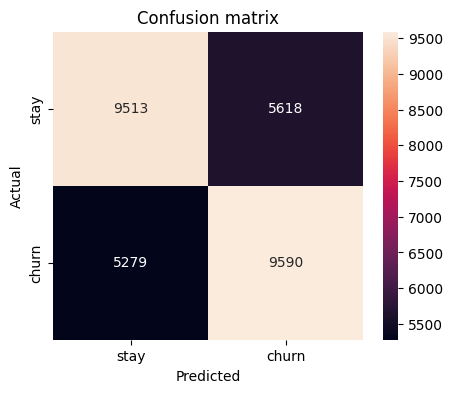

In [16]:
# Accuracy on the held-out test set
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

# Confusion matrix: rows = actual class, columns = predicted class
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['stay', 'churn'],
            yticklabels=['stay', 'churn'])
plt.title('Confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Questions to think about:**
- A baseline that always predicts the majority class would score around 0.5 here. Does your accuracy meaningfully beat that? If not, the model isn't adding evidence yet.
- Accuracy treats false positives and false negatives equally. Are they really equally costly for *your* proposal — flagging a stayer as a churner (wasted retention spend) versus missing a real churner (lost revenue)?
- What other metrics could you compute — AUC, precision, recall, F1? When would each be more informative than accuracy?
- If your accuracy looks suspiciously high, could a feature be leaking the target?

### 7.1 Feature importance

XGBoost reports several importance measures. Two simple ones: `weight` (how often a feature is used in any tree) and `gain` (how much it improves the model when used). For "which signals matter", `gain` is the more meaningful — a feature can be used often but contribute little, or rarely but decisively.

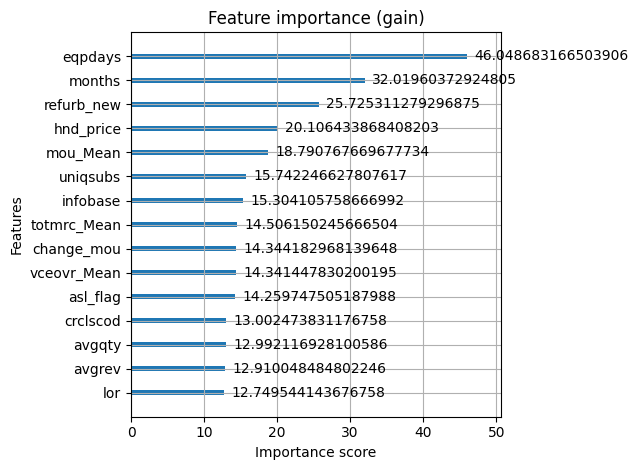

In [17]:
plot_importance(model, max_num_features=15, importance_type='gain')
plt.title('Feature importance (gain)')
plt.tight_layout()
plt.show()

**Questions to think about:**
- Pick the top 3–5 features. For each, can the business actually *change* it? Equipment age or customer-care call volume can be acted on; tenure and demographics cannot. Importance + intervenability is what produces a lever your proposal can pull.
- *Why* might each feature plausibly drive your target? Importance tells you the model uses a feature, not why — and a story a CFO can probe is what your proposal will be judged on.
- If you removed the top feature and retrained, does the next-most-important feature tell the same story, or does the ranking reshuffle? That tells you whether you have one robust signal or several correlated proxies for the same underlying driver.

---

## 8.From Model to Proposal

The model gives a probability for each customer. By itself, that is not a proposal — it is one piece of evidence. The **proposal** is the recommendation: who to target, with what action, at what cost, for what expected return. Closing the gap is the assignment, and it is what separates a passing submission from a strong one.

A common failure mode is to present the model itself as the proposal ("we built a churn model with X% accuracy"). That is a technical report. The grading rubric wants a recommendation the model supports.

**Questions to think about:**
- Concretely, what does the business *do* with a customer flagged as high risk — a retention offer? A service call? A plan change? The answer determines what counts as a successful intervention.
- If you ranked customers by predicted score and targeted the top 10% (or 20%, or some other cutoff), what fraction of actual churners would you catch? What is the right cutoff given the cost of action versus inaction?
- What is the average revenue per customer, the cost of an intervention, and the probability that the intervention actually works? Without these numbers — sourced or assumed transparently — you cannot put a dollar figure on the recommendation.
- Multiplying through (customers targeted × success rate × value retained, minus campaign cost), what is the expected impact? This is what the grading rubric means by *quantified business impact*. Show your assumptions.
- What happens if the model is wrong? What does the proposal not capture — substitution, cannibalisation, seasonality?
- How will you visualize your findings in the slides? The charts in this notebook are intentionally minimal — just enough to make a point. Your proposal slides should use polished, well-labelled visualizations that each communicate one clear takeaway. A messy chart loses your audience faster than no chart at all, and "use multiple data visualizations" is an explicit grading criterion.

A proposal that ends at *"the model predicts churn well"* is incomplete. A proposal that ends at *"targeting the top 10% of customers by predicted score yields ~$X in retained revenue under these assumptions"* is a proposal.

---

## 9.Conclusion

This is the end of the tutorial. Two things to carry forward:

- **The assignment is a business proposal backed by data, not a data analysis dressed up as a proposal.** Use the model to support a clear recommendation, with quantified impact and stated assumptions.
- **Originality counts.** A proposal that segments customers in an unusual way, reframes the problem, or grounds itself in a market you know well will stand out.

Good luck.

---

### Notes
- XGBoost in Colab: if you hit `ModuleNotFoundError`, run `!pip install xgboost` in a cell once and restart the runtime.

In [18]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0)

In [19]:
#Remove Highly Correlated Features
corr = df.corr(numeric_only=True).abs()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

drop_cols = [
    column
    for column in upper.columns
    if any(upper[column] > 0.95)
]

If two columns are 98% similar, keeping both adds noise.
Actually Remove Them. removing nosie


In [20]:
df = df.drop(columns=drop_cols)

print(df.shape)

(100000, 85)


In [21]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

cat_cols = df.select_dtypes(include=['object']).columns

In [22]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

cat_cols = df.select_dtypes(include=['object']).columns


In [23]:
from sklearn.impute import SimpleImputer

In [24]:
cat_imputer = SimpleImputer(strategy="most_frequent")
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [25]:
df.isna().sum().sort_values(ascending=False).head(20)

,0
numbcars,49366
lor,30190
income,25436
adults,23019
avg6rev,2839
truck,1732
forgntvl,1732
rv,1732
change_rev,891
change_mou,891


In [26]:
print(df.isna().sum().sum())
df[['numbcars','lor','income','adults','truck']].dtypes

141177


,0
numbcars,float64
lor,float64
income,float64
adults,float64
truck,float64


In [27]:
print(df[['numbcars','lor','income','adults','truck']].dtypes)

print()

print(df[['numbcars','lor','income','adults','truck']].head())

numbcars    float64
lor         float64
income      float64
adults      float64
truck       float64
dtype: object

   numbcars   lor  income  adults  truck
0       3.0  15.0     4.0     1.0    0.0
1       1.0   1.0     5.0     1.0    1.0
2       2.0   7.0     5.0     2.0    0.0
3       1.0   6.0     6.0     4.0    0.0
4       1.0   5.0     6.0     1.0    0.0


In [28]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

cat_cols = df.select_dtypes(include=['object']).columns

In [29]:
num_imputer = SimpleImputer(strategy='median')

df[num_cols] = num_imputer.fit_transform(df[num_cols])
print(cat_cols)

Index(['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area',
       'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype',
       'marital', 'infobase', 'HHstatin', 'dwllsize', 'ethnic', 'kid0_2',
       'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd'],
      dtype='object')


In [30]:
cat_imputer = SimpleImputer(strategy='most_frequent')

df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [31]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')

df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [32]:
print(df.select_dtypes(include='object').columns)

Index(['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area',
       'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype',
       'marital', 'infobase', 'HHstatin', 'dwllsize', 'ethnic', 'kid0_2',
       'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd'],
      dtype='object')


In [33]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

df[cat_cols] = encoder.fit_transform(df[cat_cols])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 85 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   rev_Mean          100000 non-null  float64
 1   mou_Mean          100000 non-null  float64
 2   totmrc_Mean       100000 non-null  float64
 3   da_Mean           100000 non-null  float64
 4   ovrmou_Mean       100000 non-null  float64
 5   datovr_Mean       100000 non-null  float64
 6   roam_Mean         100000 non-null  float64
 7   change_mou        100000 non-null  float64
 8   change_rev        100000 non-null  float64
 9   drop_vce_Mean     100000 non-null  float64
 10  drop_dat_Mean     100000 non-null  float64
 11  blck_vce_Mean     100000 non-null  float64
 12  blck_dat_Mean     100000 non-null  float64
 13  unan_vce_Mean     100000 non-null  float64
 14  unan_dat_Mean     100000 non-null  float64
 15  plcd_vce_Mean     100000 non-null  float64
 16  plcd_dat_Mean     100

In [34]:
print(df.shape)
df.info()

(100000, 85)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 85 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   rev_Mean          100000 non-null  float64
 1   mou_Mean          100000 non-null  float64
 2   totmrc_Mean       100000 non-null  float64
 3   da_Mean           100000 non-null  float64
 4   ovrmou_Mean       100000 non-null  float64
 5   datovr_Mean       100000 non-null  float64
 6   roam_Mean         100000 non-null  float64
 7   change_mou        100000 non-null  float64
 8   change_rev        100000 non-null  float64
 9   drop_vce_Mean     100000 non-null  float64
 10  drop_dat_Mean     100000 non-null  float64
 11  blck_vce_Mean     100000 non-null  float64
 12  blck_dat_Mean     100000 non-null  float64
 13  unan_vce_Mean     100000 non-null  float64
 14  unan_dat_Mean     100000 non-null  float64
 15  plcd_vce_Mean     100000 non-null  float64
 16  plcd_dat

In [35]:
print(df["churn"].value_counts())

print(df["churn"].value_counts(normalize=True))

churn
0.0    50438
1.0    49562
Name: count, dtype: int64
churn
0.0    0.50438
1.0    0.49562
Name: proportion, dtype: float64


In [36]:
df["customer_value"] = df["months"] * df["rev_Mean"]

df["network_issue_score"] = (
    df["drop_vce_Mean"] +
    df["blck_vce_Mean"] +
    df["unan_vce_Mean"]
)

df["usage_score"] = (
    df["totmou"] +
    df["totcalls"]
)

df["revenue_per_month"] = (
    df["rev_Mean"] /
    (df["months"] + 1)
)

df["device_age_ratio"] = (
    df["eqpdays"] /
    (df["months"] + 1)
)

In [37]:
corr = df.corr()

corr["churn"].sort_values(key=abs, ascending=False).head(20)

,churn
churn,1.000000
eqpdays,0.112693
hnd_price,-0.102680
device_age_ratio,0.088656
asl_flag,-0.069473
totmrc_Mean,-0.068503
mou_Mean,-0.057326
mou_cvce_Mean,-0.052042
mou_opkv_Mean,-0.048896
hnd_webcap,-0.048884


In [38]:
from sklearn.model_selection import train_test_split

X = df.drop("churn", axis=1)
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(80000, 89)
(20000, 89)
(80000,)
(20000,)


In [40]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [41]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.6359
Precision: 0.6289468523239851
Recall   : 0.6470944309927361
F1 Score : 0.6378915962207857
ROC AUC  : 0.6923303540626186


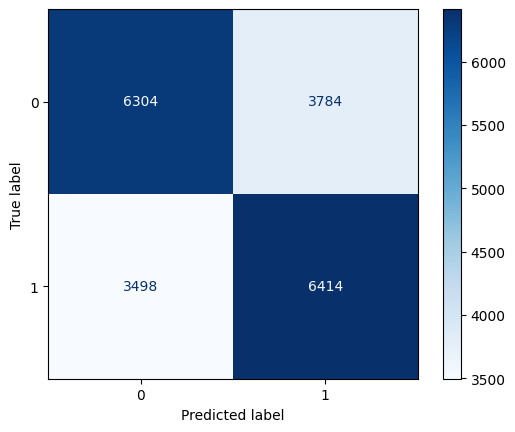

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.show()

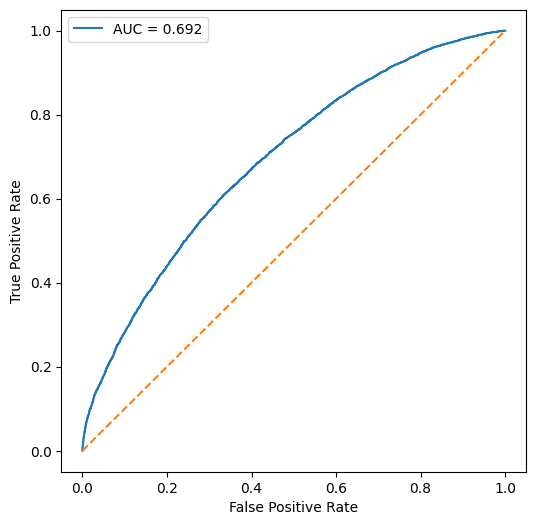

In [44]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test,y_prob):.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [45]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
83,eqpdays,0.067818
39,months,0.042390
58,refurb_new,0.039519
59,hnd_price,0.023237
1,mou_Mean,0.020846
41,uniqsubs,0.019713
82,creditcd,0.017961
45,asl_flag,0.017727
2,totmrc_Mean,0.017668
51,avgqty,0.016059


In [46]:
top20 = importance.head(20)

print(top20)

          Feature  Importance
83        eqpdays    0.067818
39         months    0.042390
58     refurb_new    0.039519
59      hnd_price    0.023237
1        mou_Mean    0.020846
41       uniqsubs    0.019713
82       creditcd    0.017961
45       asl_flag    0.017727
2     totmrc_Mean    0.017668
51         avgqty    0.016059
7      change_mou    0.015844
22  mou_cvce_Mean    0.015652
44       crclscod    0.014681
66            lor    0.014358
4     ovrmou_Mean    0.014193
49         avgrev    0.013508
46       totcalls    0.013278
50         avgmou    0.013133
68        marital    0.012366
8      change_rev    0.012048


In [47]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.3 MB/s eta 0:00:00


In [48]:
from catboost import CatBoostClassifier

In [49]:
cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=8,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

In [50]:
cat_model.fit(
    X_train,
    y_train
)

0:	total: 156ms	remaining: 2m 36s
100:	total: 20.9s	remaining: 3m 5s
200:	total: 37.3s	remaining: 2m 28s
300:	total: 47.8s	remaining: 1m 51s
400:	total: 57.6s	remaining: 1m 25s
500:	total: 1m 6s	remaining: 1m 6s
600:	total: 1m 17s	remaining: 51.3s
700:	total: 1m 27s	remaining: 37.2s
800:	total: 1m 36s	remaining: 23.9s
900:	total: 1m 46s	remaining: 11.7s
999:	total: 1m 58s	remaining: 0us


CatBoostClassifier(depth=8, eval_metric='AUC', iterations=1000, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=100)

In [51]:
y_pred_cat = cat_model.predict(X_test)

y_prob_cat = cat_model.predict_proba(X_test)[:, 1]

In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_cat))
print("Precision:", precision_score(y_test, y_pred_cat))
print("Recall   :", recall_score(y_test, y_pred_cat))
print("F1 Score :", f1_score(y_test, y_pred_cat))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_cat))

Accuracy : 0.6364
Precision: 0.6292596944770857
Recall   : 0.6483050847457628
F1 Score : 0.6386404293381037
ROC AUC  : 0.6957371278831832


In [53]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cat_scores = cross_val_score(
    cat_model,
    X,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Fold Scores:", cat_scores)
print("Mean ROC AUC:", cat_scores.mean())
print("Standard Deviation:", cat_scores.std())

Fold Scores: [0.6937559  0.70382463 0.69412123 0.69876301 0.69812394]
Mean ROC AUC: 0.6977177441089173
Standard Deviation: 0.003665590485337909


In [54]:
cat_model.save_model("catboost_churn_model.cbm")

In [55]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.8 MB/s eta 0:00:00


In [56]:
import optuna

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [66]:
def objective(trial):

    params = {

        "iterations": trial.suggest_int("iterations", 200, 600),

        "depth": trial.suggest_int("depth", 4, 8),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.02,
            0.2,
            log=True
        ),

        "l2_leaf_reg": trial.suggest_int(
            "l2_leaf_reg",
            1,
            8
        ),

        "loss_function":"Logloss",
        "eval_metric":"AUC",
        "verbose":False,
        "random_seed":42
    }

    # THIS LINE IS REQUIRED
    model = CatBoostClassifier(**params)

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    score = cross_val_score(
        model,
        X_small,
        y_small,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    return score

In [68]:
study = optuna.create_study(direction="maximize")

study.optimize(
    objective,
    n_trials=10
)

[I 2026-06-28 10:12:00,410] A new study created in memory with name: no-name-a29b3de3-e106-4746-b24f-eef2968814a3
[I 2026-06-28 10:13:49,241] Trial 0 finished with value: 0.685977545155801 and parameters: {'iterations': 453, 'depth': 7, 'learning_rate': 0.05160765686282715, 'l2_leaf_reg': 6}. Best is trial 0 with value: 0.685977545155801.
[I 2026-06-28 10:14:53,828] Trial 1 finished with value: 0.6831365151394404 and parameters: {'iterations': 278, 'depth': 7, 'learning_rate': 0.06325991424023897, 'l2_leaf_reg': 7}. Best is trial 0 with value: 0.685977545155801.
[I 2026-06-28 10:15:51,101] Trial 2 finished with value: 0.6820413312894269 and parameters: {'iterations': 341, 'depth': 6, 'learning_rate': 0.1495668518254676, 'l2_leaf_reg': 5}. Best is trial 0 with value: 0.685977545155801.
[I 2026-06-28 10:16:21,561] Trial 3 finished with value: 0.6828822831748056 and parameters: {'iterations': 229, 'depth': 5, 'learning_rate': 0.11921029294448553, 'l2_leaf_reg': 5}. Best is trial 0 with va

In [70]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=1000,
    depth=8,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)

cat_model.fit(X_train, y_train)

0:	total: 360ms	remaining: 5m 59s
100:	total: 14.4s	remaining: 2m 7s
200:	total: 23.8s	remaining: 1m 34s
300:	total: 34.4s	remaining: 1m 19s
400:	total: 44.4s	remaining: 1m 6s
500:	total: 53.4s	remaining: 53.2s
600:	total: 1m 3s	remaining: 42.4s
700:	total: 1m 14s	remaining: 31.6s
800:	total: 1m 22s	remaining: 20.6s
900:	total: 1m 33s	remaining: 10.2s
999:	total: 1m 43s	remaining: 0us


CatBoostClassifier(depth=8, eval_metric='AUC', iterations=1000, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=100)

In [71]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": cat_model.get_feature_importance()
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(30)

,Feature,Importance
39,months,6.211038
7,change_mou,6.129766
1,mou_Mean,5.522268
83,eqpdays,5.030013
2,totmrc_Mean,4.546772
8,change_rev,3.370295
44,crclscod,2.908427
59,hnd_price,2.774521
88,device_age_ratio,2.483412
4,ovrmou_Mean,2.421203


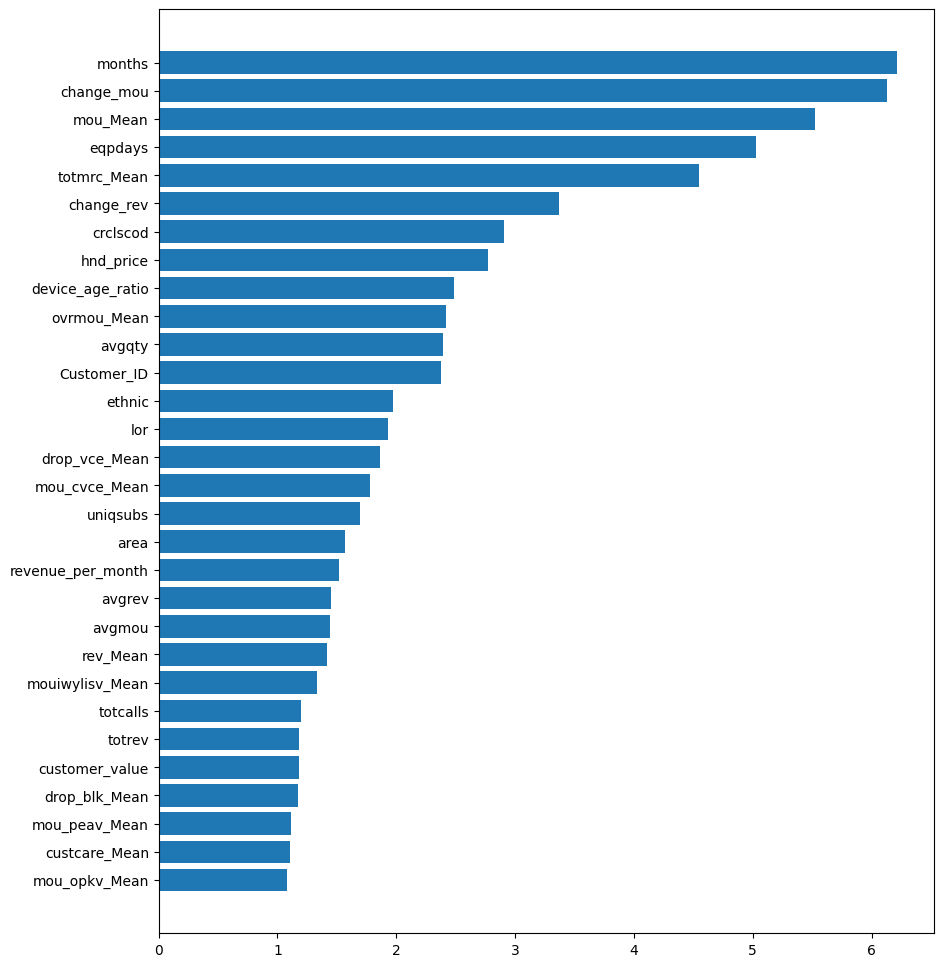

In [72]:
import matplotlib.pyplot as plt

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,12))
plt.barh(
    importance["Feature"][:30],
    importance["Importance"][:30]
)
plt.gca().invert_yaxis()
plt.show()

In [73]:
df = df.drop(columns=["Customer_ID"])

In [74]:
X = df.drop("churn", axis=1)
y = df["churn"]

In [75]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": cat_model.get_feature_importance()
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.tail(25)

,Feature,Importance
43,new_cell,0.291979
32,mou_pead_Mean,0.287419
62,hnd_webcap,0.285728
23,mou_cdat_Mean,0.277865
72,numbcars,0.242450
5,datovr_Mean,0.207262
74,dwllsize,0.173265
67,dwlltype,0.156292
63,truck,0.126748
18,recv_sms_Mean,0.105949


In [77]:
df = df.drop(columns=["callfwdv_Mean"])

In [78]:
X = df.drop("churn", axis=1)
y = df["churn"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [79]:
cat_model = CatBoostClassifier(
    iterations=1000,
    depth=8,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	test: 0.6270946	best: 0.6270946 (0)	total: 270ms	remaining: 4m 29s
100:	test: 0.6706798	best: 0.6706798 (100)	total: 12.9s	remaining: 1m 54s
200:	test: 0.6799905	best: 0.6799905 (200)	total: 21.9s	remaining: 1m 27s
300:	test: 0.6838836	best: 0.6838836 (300)	total: 32.6s	remaining: 1m 15s
400:	test: 0.6874100	best: 0.6874100 (400)	total: 43.2s	remaining: 1m 4s
500:	test: 0.6909293	best: 0.6909293 (500)	total: 51.8s	remaining: 51.6s
600:	test: 0.6928306	best: 0.6928675 (597)	total: 1m 2s	remaining: 41.4s
700:	test: 0.6944448	best: 0.6944448 (700)	total: 1m 13s	remaining: 31.2s
800:	test: 0.6951142	best: 0.6951616 (797)	total: 1m 21s	remaining: 20.3s
900:	test: 0.6955507	best: 0.6955937 (895)	total: 1m 32s	remaining: 10.2s
999:	test: 0.6959099	best: 0.6959099 (999)	total: 1m 44s	remaining: 0us

bestTest = 0.6959098613
bestIteration = 999



CatBoostClassifier(depth=8, eval_metric='AUC', iterations=1000, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=100)

In [80]:
# Revenue and usage efficiency
df["rev_per_call"] = df["totrev"] / (df["totcalls"] + 1)
df["mou_per_call"] = df["totmou"] / (df["totcalls"] + 1)

# Monthly averages
df["rev_per_month"] = df["totrev"] / (df["months"] + 1)
df["calls_per_month"] = df["totcalls"] / (df["months"] + 1)
df["mou_per_month"] = df["totmou"] / (df["months"] + 1)

# Customer value
df["rev_per_sub"] = df["totrev"] / (df["uniqsubs"] + 1)

# Usage trends
df["mou_change_ratio"] = df["change_mou"] / (df["mou_Mean"] + 1)
df["rev_change_ratio"] = df["change_rev"] / (df["rev_Mean"] + 1)

# Device utilization
df["device_cost_per_day"] = df["hnd_price"] / (df["eqpdays"] + 1)

In [81]:
X = df.drop("churn", axis=1)
y = df["churn"]

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [83]:
print(df.columns.tolist())

['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou', 'change_rev', 'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean', 'blck_dat_Mean', 'unan_vce_Mean', 'unan_dat_Mean', 'plcd_vce_Mean', 'plcd_dat_Mean', 'recv_vce_Mean', 'recv_sms_Mean', 'custcare_Mean', 'ccrndmou_Mean', 'threeway_Mean', 'mou_cvce_Mean', 'mou_cdat_Mean', 'mou_rvce_Mean', 'owylis_vce_Mean', 'mouowylisv_Mean', 'iwylis_vce_Mean', 'mouiwylisv_Mean', 'peak_vce_Mean', 'peak_dat_Mean', 'mou_peav_Mean', 'mou_pead_Mean', 'opk_vce_Mean', 'opk_dat_Mean', 'mou_opkv_Mean', 'drop_blk_Mean', 'callwait_Mean', 'churn', 'months', 'uniqsubs', 'actvsubs', 'new_cell', 'crclscod', 'asl_flag', 'totcalls', 'totmou', 'totrev', 'avgrev', 'avgmou', 'avgqty', 'avg3qty', 'avg3rev', 'avg6rev', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_price', 'phones', 'models', 'hnd_webcap', 'truck', 'rv', 'ownrent', 'lor', 'dwlltype', 'marital', 'adults', 'infobase', 'income', 'numbcars', 'HHs

In [86]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=2000,
    depth=8,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	test: 0.6442356	best: 0.6442356 (0)	total: 416ms	remaining: 13m 52s
100:	test: 0.6777397	best: 0.6777397 (100)	total: 19.6s	remaining: 6m 8s
200:	test: 0.6855212	best: 0.6855842 (199)	total: 29.4s	remaining: 4m 23s
300:	test: 0.6901131	best: 0.6901383 (297)	total: 41s	remaining: 3m 51s
400:	test: 0.6932060	best: 0.6932060 (400)	total: 52.7s	remaining: 3m 30s
500:	test: 0.6957721	best: 0.6957998 (495)	total: 1m 4s	remaining: 3m 12s
600:	test: 0.6973390	best: 0.6973540 (598)	total: 1m 14s	remaining: 2m 53s
700:	test: 0.6980887	best: 0.6981003 (698)	total: 1m 25s	remaining: 2m 38s
800:	test: 0.6992451	best: 0.6992451 (800)	total: 1m 37s	remaining: 2m 26s
900:	test: 0.7000021	best: 0.7000061 (898)	total: 1m 50s	remaining: 2m 14s
1000:	test: 0.7007569	best: 0.7007984 (997)	total: 2m 2s	remaining: 2m 2s
1100:	test: 0.7009580	best: 0.7010636 (1052)	total: 2m 12s	remaining: 1m 48s
1200:	test: 0.7011241	best: 0.7011241 (1200)	total: 2m 24s	remaining: 1m 36s
1300:	test: 0.7012824	best: 0.7012

CatBoostClassifier(depth=8, eval_metric='AUC', iterations=2000, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=100)

In [87]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred = cat_model.predict(X_test)
y_prob = cat_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.6416
Precision: 0.6372
Recall   : 0.6428571428571429
F1 Score : 0.640016070711129
ROC AUC  : 0.7016869686388514


In [88]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": cat_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
93,mou_change_ratio,5.742418
38,months,5.443215
2,totmrc_Mean,3.631229
81,eqpdays,3.622108
94,rev_change_ratio,3.226696
...,...,...
62,rv,0.056579
10,drop_dat_Mean,0.054856
77,kid6_10,0.053309
73,forgntvl,0.015652


In [90]:
importance.sort_values("Importance").head(20)

,Feature,Importance
68,infobase,0.014039
73,forgntvl,0.015652
77,kid6_10,0.053309
10,drop_dat_Mean,0.054856
62,rv,0.056579
75,kid0_2,0.060068
12,blck_dat_Mean,0.061683
14,unan_dat_Mean,0.064213
63,ownrent,0.076460
30,peak_dat_Mean,0.079647


In [91]:
df = df.drop(columns=[
    "infobase",
    "forgntvl"
])

In [93]:
y_pred = cat_model.predict(X_test)
y_prob = cat_model.predict_proba(X_test)[:,1]

print("ROC AUC:", roc_auc_score(y_test, y_prob))

ROC AUC: 0.7016869686388514


In [97]:
cat_model.fit(X_train, y_train, eval_set=(X_test, y_test))

0:	test: 0.6442356	best: 0.6442356 (0)	total: 115ms	remaining: 3m 49s
100:	test: 0.6777397	best: 0.6777397 (100)	total: 12s	remaining: 3m 46s
200:	test: 0.6855212	best: 0.6855842 (199)	total: 27.9s	remaining: 4m 9s
300:	test: 0.6901131	best: 0.6901383 (297)	total: 40s	remaining: 3m 45s
400:	test: 0.6932060	best: 0.6932060 (400)	total: 51.5s	remaining: 3m 25s
500:	test: 0.6957721	best: 0.6957998 (495)	total: 1m 1s	remaining: 3m 2s
600:	test: 0.6973390	best: 0.6973540 (598)	total: 1m 12s	remaining: 2m 49s
700:	test: 0.6980887	best: 0.6981003 (698)	total: 1m 24s	remaining: 2m 36s
800:	test: 0.6992451	best: 0.6992451 (800)	total: 1m 35s	remaining: 2m 23s
900:	test: 0.7000021	best: 0.7000061 (898)	total: 1m 46s	remaining: 2m 9s
1000:	test: 0.7007569	best: 0.7007984 (997)	total: 1m 57s	remaining: 1m 57s
1100:	test: 0.7009580	best: 0.7010636 (1052)	total: 2m 9s	remaining: 1m 45s
1200:	test: 0.7011241	best: 0.7011241 (1200)	total: 2m 21s	remaining: 1m 33s
1300:	test: 0.7012824	best: 0.7012863 

CatBoostClassifier(depth=8, eval_metric='AUC', iterations=2000, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=100)

In [98]:
y_pred = cat_model.predict(X_test)
y_prob = cat_model.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, y_prob)

np.float64(0.7016869686388514)

In [99]:
print(X_train.shape)
print(X_test.shape)

(80000, 96)
(20000, 96)


In [100]:
# Revenue efficiency
df["rev_per_mou"] = df["rev_Mean"] / (df["mou_Mean"] + 1)

# Messages per revenue
df["sms_per_rev"] = df["recv_sms_Mean"] / (df["rev_Mean"] + 1)

# Roaming ratio
df["roam_ratio"] = df["roam_Mean"] / (df["mou_Mean"] + 1)

# Revenue per month
df["rev_per_month"] = df["rev_Mean"] / (df["months"] + 1)

# Total usage
df["total_usage"] = (
    df["mou_Mean"] +
    df["totmrc_Mean"] +
    df["da_Mean"]
)

# Call quality
df["drop_rate"] = (
    df["drop_vce_Mean"] /
    (df["mou_Mean"] + 1)
)

# Device age efficiency
df["device_age_efficiency"] = (
    df["eqpdays"] /
    (df["months"] + 1)
)

# Revenue stability
df["rev_stability"] = (
    abs(df["change_rev"]) /
    (df["rev_Mean"] + 1)
)

/tmp/ipykernel_208/4025616062.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["device_age_efficiency"] = (
/tmp/ipykernel_208/4025616062.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["rev_stability"] = (


In [101]:
X = df.drop("churn", axis=1)
y = df["churn"]

In [102]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [103]:
cat_model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	test: 0.6266682	best: 0.6266682 (0)	total: 262ms	remaining: 8m 44s
100:	test: 0.6788747	best: 0.6788747 (100)	total: 17.3s	remaining: 5m 25s
200:	test: 0.6871935	best: 0.6871935 (200)	total: 32s	remaining: 4m 46s
300:	test: 0.6906919	best: 0.6906919 (300)	total: 44.6s	remaining: 4m 11s
400:	test: 0.6940870	best: 0.6940870 (400)	total: 57.1s	remaining: 3m 47s
500:	test: 0.6964551	best: 0.6964627 (498)	total: 1m 10s	remaining: 3m 29s
600:	test: 0.6980888	best: 0.6980888 (600)	total: 1m 22s	remaining: 3m 11s
700:	test: 0.6987162	best: 0.6988466 (658)	total: 1m 32s	remaining: 2m 51s
800:	test: 0.6995109	best: 0.6995109 (800)	total: 1m 44s	remaining: 2m 37s
900:	test: 0.7001109	best: 0.7001109 (900)	total: 1m 57s	remaining: 2m 22s
1000:	test: 0.7003591	best: 0.7004134 (997)	total: 2m 9s	remaining: 2m 9s
1100:	test: 0.7010610	best: 0.7010851 (1099)	total: 2m 21s	remaining: 1m 55s
1200:	test: 0.7012249	best: 0.7012676 (1189)	total: 2m 33s	remaining: 1m 41s
1300:	test: 0.7015292	best: 0.701

CatBoostClassifier(depth=8, eval_metric='AUC', iterations=2000, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=100)

In [104]:
from sklearn.metrics import roc_auc_score

y_prob = cat_model.predict_proba(X_test)[:, 1]

print("ROC AUC:", roc_auc_score(y_test, y_prob))

ROC AUC: 0.7020358856589854


In [105]:
import joblib

joblib.dump(cat_model, "catboost_final.pkl")

['catboost_final.pkl']

In [106]:
import joblib

joblib.dump(cat_model, "catboost_final.pkl")

['catboost_final.pkl']

In [108]:
print(df.shape)

(100000, 102)


In [109]:
import os
os.listdir()

['ENG_Company _A_ Dataset Overview.docx',
 'README.docx',
 'info.docx',
 'telecom',
 'tutorial.ipynb',
 'catboost_info',
 'catboost_churn_model.cbm',
 'catboost_final.pkl']

In [110]:
df["churn_probability"] = cat_model.predict_proba(X)[:, 1]

/tmp/ipykernel_208/1249458941.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["churn_probability"] = cat_model.predict_proba(X)[:, 1]


In [111]:
df["Risk"] = pd.cut(
    df["churn_probability"],
    bins=[0, 0.3, 0.7, 1],
    labels=["Low", "Medium", "High"]
)

/tmp/ipykernel_208/2616020069.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Risk"] = pd.cut(


In [112]:
df["Risk"] = pd.cut(
    df["churn_probability"],
    bins=[0, 0.3, 0.7, 1],
    labels=["Low", "Medium", "High"]
)

In [115]:
df["Risk"].value_counts(normalize=True) * 100
df["Risk"].value_counts()

,count
Risk,
Medium,65605
Low,18595
High,15800


In [117]:
print(df.columns.tolist())

['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou', 'change_rev', 'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean', 'blck_dat_Mean', 'unan_vce_Mean', 'unan_dat_Mean', 'plcd_vce_Mean', 'plcd_dat_Mean', 'recv_vce_Mean', 'recv_sms_Mean', 'custcare_Mean', 'ccrndmou_Mean', 'threeway_Mean', 'mou_cvce_Mean', 'mou_cdat_Mean', 'mou_rvce_Mean', 'owylis_vce_Mean', 'mouowylisv_Mean', 'iwylis_vce_Mean', 'mouiwylisv_Mean', 'peak_vce_Mean', 'peak_dat_Mean', 'mou_peav_Mean', 'mou_pead_Mean', 'opk_vce_Mean', 'opk_dat_Mean', 'mou_opkv_Mean', 'drop_blk_Mean', 'callwait_Mean', 'churn', 'months', 'uniqsubs', 'actvsubs', 'new_cell', 'crclscod', 'asl_flag', 'totcalls', 'totmou', 'totrev', 'avgrev', 'avgmou', 'avgqty', 'avg3qty', 'avg3rev', 'avg6rev', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_price', 'phones', 'models', 'hnd_webcap', 'truck', 'rv', 'ownrent', 'lor', 'dwlltype', 'marital', 'adults', 'income', 'numbcars', 'HHstatin', 'dwl

In [118]:
print("Average churn probability:",
      df["churn_probability"].mean())

Average churn probability: 0.4957783953671306


In [119]:
print("Maximum churn probability:",
      df["churn_probability"].max())

Maximum churn probability: 0.986001437617481


In [120]:
print("Minimum churn probability:",
      df["churn_probability"].min())

Minimum churn probability: 0.016548878034233504


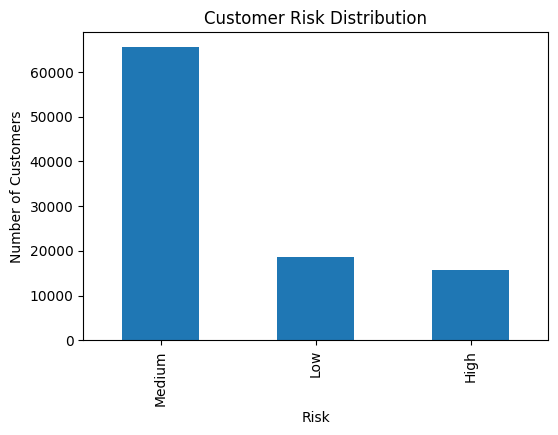

In [121]:
import matplotlib.pyplot as plt

df["Risk"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Customer Risk Distribution")
plt.ylabel("Number of Customers")
plt.show()

In [122]:
top20 = df.sort_values(
    "churn_probability",
    ascending=False
).head(20)

top20

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,custcare_Mean,ccrndmou_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,drop_blk_Mean,callwait_Mean,churn,months,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,avgrev,avgmou,avgqty,avg3qty,avg3rev,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,income,numbcars,HHstatin,dwllsize,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,customer_value,network_issue_score,usage_score,revenue_per_month,device_age_ratio,rev_per_call,mou_per_call,rev_per_month,calls_per_month,mou_per_month,rev_per_sub,mou_change_ratio,rev_change_ratio,device_cost_per_day,rev_per_mou,sms_per_rev,roam_ratio,total_usage,drop_rate,device_age_efficiency,rev_stability,churn_probability,Risk
18165,5.0000,0.00,0.0000,0.0000,0.00,0.0,0.00,-6.25,-0.3150,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,1.0,23.0,3.0,2.0,1.0,6.0,0.0,2145.0,4615.0,599.10,40.64,384.45,183.18,526.0,78.0,48.0,2.0,3.0,3.0,1.0,99.989990,3.0,2.0,2.0,0.0,0.0,0.0,5.0,1.0,4.0,2.0,6.0,1.0,2.0,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,380.0,115.0000,0.000000,6760.0,0.208333,15.833333,0.279171,2.150513,0.208333,89.375000,192.291667,149.775000,-6.250000,-0.052500,0.262441,5.000000,0.0,0.0000,0.00,0.000000,15.833333,0.052500,0.986001,High
73428,5.0000,0.00,0.0000,0.0000,0.00,0.0,0.00,-6.25,-0.3150,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,1.0,8.0,3.0,2.0,1.0,6.0,0.0,583.0,3033.0,379.93,78.74,733.75,139.75,119.0,83.0,50.0,0.0,17.0,3.0,0.0,199.989990,2.0,2.0,2.0,0.0,0.0,0.0,5.0,1.0,4.0,2.0,6.0,1.0,2.0,0.0,13.0,0.0,0.0,0.0,0.0,0.0,0.0,229.0,40.0000,0.000000,3616.0,0.555556,25.444444,0.650565,5.193493,0.555556,64.777778,337.000000,94.982500,-6.250000,-0.052500,0.869522,5.000000,0.0,0.0000,0.00,0.000000,25.444444,0.052500,0.985010,High
50754,5.0000,0.00,0.0000,0.0000,0.00,0.0,0.00,-6.25,-0.3150,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,1.0,13.0,2.0,2.0,1.0,6.0,0.0,1532.0,4006.0,671.80,141.70,984.25,377.50,256.0,90.0,50.0,2.0,13.0,3.0,0.0,129.989990,1.0,1.0,2.0,0.0,0.0,0.0,5.0,1.0,4.0,2.0,6.0,1.0,2.0,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,385.0,65.0000,0.000000,5538.0,0.357143,27.500000,0.438226,2.613177,0.357143,109.428571,286.142857,223.933333,-6.250000,-0.052500,0.336762,5.000000,0.0,0.0000,0.00,0.000000,27.500000,0.052500,0.983801,High
45979,5.0000,0.00,0.0000,0.0000,0.00,0.0,0.00,-6.25,-0.3150,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,1.0,20.0,2.0,2.0,1.0,3.0,0.0,4025.0,10786.0,860.32,94.42,1346.13,502.63,136.0,25.0,98.0,3.0,1.0,3.0,1.0,79.989990,2.0,2.0,2.0,0.0,0.0,0.0,5.0,1.0,2.0,4.0,6.0,2.0,2.0,0.0,4.0,0.0,0.0,0.0,1.0,1.0,1.0,477.0,100.0000,0.000000,14811.0,0.238095,22.714286,0.213691,2.679086,0.238095,191.666667,513.619048,286.773333,-6.250000,-0.052500,0.167343,5.000000,0.0,0.0000,0.00,0.000000,22.714286,0.052500,0.983330,High
11694,5.0000,0.00,0.0000,0.0000,0.00,0.0,0.00,-6.25,-0.3150,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.00000

In [123]:
df.groupby("Risk")["churn"].mean()

/tmp/ipykernel_208/2635067242.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Risk")["churn"].mean()


,churn
Risk,
Low,0.081635
Medium,0.509412
High,0.925570


In [124]:
df.groupby("Risk")["rev_Mean"].mean()

/tmp/ipykernel_208/2435304044.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Risk")["rev_Mean"].mean()


,rev_Mean
Risk,
Low,63.512330
Medium,56.822849
High,60.719384


In [125]:
df.groupby("Risk")["months"].mean()

/tmp/ipykernel_208/2120878192.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Risk")["months"].mean()


,months
Risk,
Low,16.932240
Medium,19.345629
High,18.947722


In [126]:
df.groupby("Risk")["mou_Mean"].mean()

/tmp/ipykernel_208/2503223626.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Risk")["mou_Mean"].mean()


,mou_Mean
Risk,
Low,658.052317
Medium,489.823420
High,438.494807


In [127]:
business_summary = df.groupby("Risk").agg({
    "churn":"mean",
    "rev_Mean":"mean",
    "months":"mean",
    "mou_Mean":"mean"
})

business_summary

/tmp/ipykernel_208/4166340970.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  business_summary = df.groupby("Risk").agg({


,churn,rev_Mean,months,mou_Mean
Risk,,,,
Low,0.081635,63.512330,16.932240,658.052317
Medium,0.509412,56.822849,19.345629,489.823420
High,0.925570,60.719384,18.947722,438.494807


In [128]:
business_summary = (
    df.groupby("Risk")
      .agg(
          Customers=("Risk", "count"),
          Churn_Rate=("churn", "mean"),
          Avg_Revenue=("rev_Mean", "mean"),
          Avg_Usage=("mou_Mean", "mean"),
          Avg_Tenure=("months", "mean")
      )
)

business_summary["Churn_Rate"] *= 100

business_summary.round(2)

/tmp/ipykernel_208/1251643162.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Risk")


,Customers,Churn_Rate,Avg_Revenue,Avg_Usage,Avg_Tenure
Risk,,,,,
Low,18595,8.16,63.51,658.05,16.93
Medium,65605,50.94,56.82,489.82,19.35
High,15800,92.56,60.72,438.49,18.95


<Axes: xlabel='Risk'>

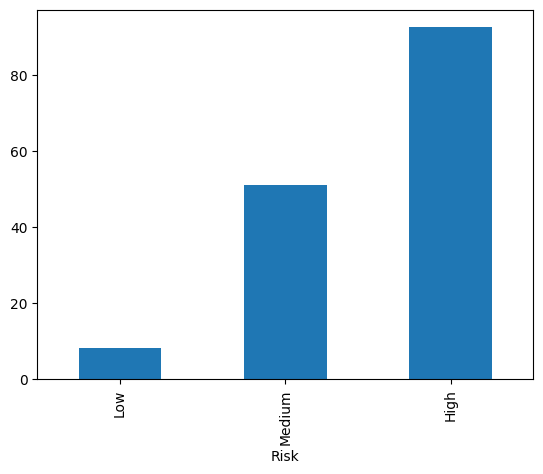

In [129]:
business_summary["Churn_Rate"].plot(kind="bar")

<Axes: xlabel='Risk'>

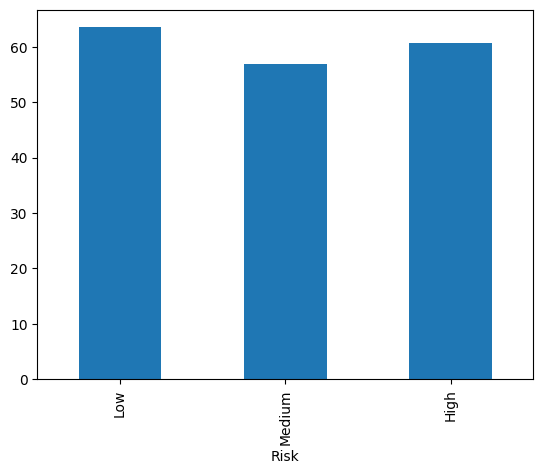

In [130]:
business_summary["Avg_Revenue"].plot(kind="bar")

<Axes: xlabel='Risk'>

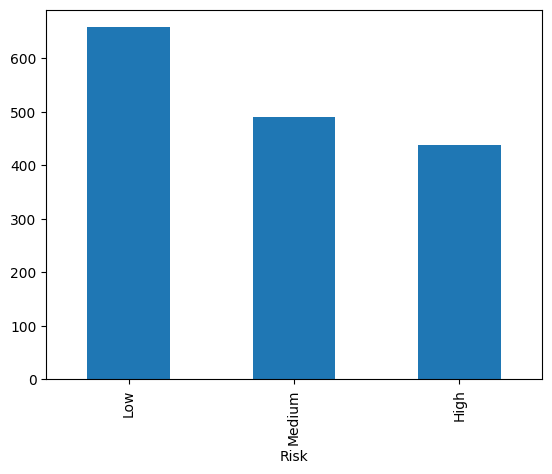

In [131]:
business_summary["Avg_Usage"].plot(kind="bar")

<Axes: ylabel='Customers'>

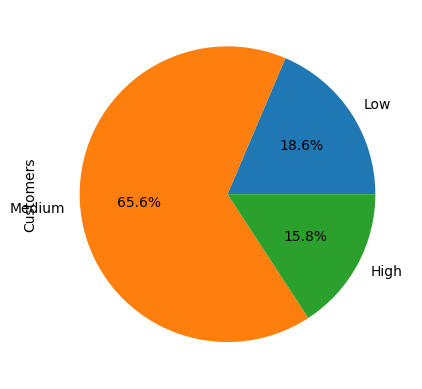

In [132]:
business_summary["Customers"].plot(kind="pie", autopct="%1.1f%%")

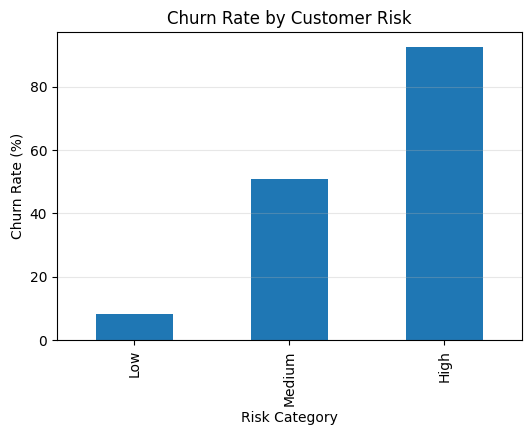

In [133]:
plt.figure(figsize=(6,4))
business_summary["Churn_Rate"].plot(kind="bar")
plt.title("Churn Rate by Customer Risk")
plt.xlabel("Risk Category")
plt.ylabel("Churn Rate (%)")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [134]:
business_summary

,Customers,Churn_Rate,Avg_Revenue,Avg_Usage,Avg_Tenure
Risk,,,,,
Low,18595,8.163485,63.512330,658.052317,16.932240
Medium,65605,50.941239,56.822849,489.823420,19.345629
High,15800,92.556962,60.719384,438.494807,18.947722


In [135]:
saved_customers = 15800 * 0.30
print(saved_customers)

4740.0


In [136]:
saved_customers = 15800 * 0.30

avg_revenue = business_summary.loc["High","Avg_Revenue"]

monthly_revenue_saved = saved_customers * avg_revenue

print(monthly_revenue_saved)

287809.8790000428
